# 🕹️ Analyse du marché des jeux Steam

Projet de fin de formation Jedha – Mission d’analyse pour **Ubisoft**

Objectifs principaux :

- Comprendre la structure du catalogue Steam (genres, plateformes, âges, langues, prix…)
- Identifier les **facteurs de popularité** (reviews, notes, prix…)
- Analyser l’impact de la **période COVID**
- Dégager des **opportunités marché** pour le lancement d’un nouveau jeu Ubisoft

## Plan du notebook

1.  Setup & chargement des données  
2.  Diagnostic du schéma brut (sans champs cachés)  
3.  Construction de la table principale `games_df`  
4.  Nettoyage & Feature Engineering (types, dates, reviews, COVID)  
5.  Analyse macro du marché (années, publishers, prix, âges…)  
6.  Analyse par genres (fréquence, satisfaction, plateformes)  
7.  Analyse par plateformes (Windows / Mac / Linux)  
8.  Synthèse & recommandations business pour Ubisoft

In [0]:
# 1. Setup & chargement des données depuis S3 (PySpark / Databricks)

from pyspark.sql import functions as F
from pyspark.sql import types as T
import json

# Chemin fourni par Jedha
steam_path = "s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json"

# Lecture du JSON semi-structuré
df = spark.read.json(steam_path)

print("Données chargées depuis :", steam_path)
print("Nombre de lignes:", df.count())

✅ Données chargées depuis : s3://full-stack-bigdata-datasets/Big_Data/Project_Steam/steam_game_output.json
✅ Nombre de lignes: 55691


## 2. Diagnostic du schéma brut

Avant de construire notre table métier `games_df`, on veut vérifier :

- la structure exacte de `data` (struct imbriquée)
- la présence des champs clés : `appid`, `name`, `genre`, `publisher`, `price`, `initialprice`, `discount`, `platforms`, `release_date`, `positive`, `negative`, `languages`, `owners`, `ccu`, etc.

On affiche le schéma en JSON pour **ne cacher aucune colonne**, même si elle est imbriquée.

In [0]:
# 2. Schéma complet en JSON

print("SCHÉMA COMPLET en JSON")
print(df.schema.json())

print("SCHÉMA COMPLET (JSON indenté)")
print(json.dumps(df.schema.jsonValue(), indent=2))

SCHÉMA COMPLET en JSON
{"fields":[{"metadata":{},"name":"data","nullable":true,"type":{"fields":[{"metadata":{},"name":"appid","nullable":true,"type":"long"},{"metadata":{},"name":"categories","nullable":true,"type":{"containsNull":true,"elementType":"string","type":"array"}},{"metadata":{},"name":"ccu","nullable":true,"type":"long"},{"metadata":{},"name":"developer","nullable":true,"type":"string"},{"metadata":{},"name":"discount","nullable":true,"type":"string"},{"metadata":{},"name":"genre","nullable":true,"type":"string"},{"metadata":{},"name":"header_image","nullable":true,"type":"string"},{"metadata":{},"name":"initialprice","nullable":true,"type":"string"},{"metadata":{},"name":"languages","nullable":true,"type":"string"},{"metadata":{},"name":"name","nullable":true,"type":"string"},{"metadata":{},"name":"negative","nullable":true,"type":"long"},{"metadata":{},"name":"owners","nullable":true,"type":"string"},{"metadata":{},"name":"platforms","nullable":true,"type":{"fields":[{"m

## 3. Construction de la table principale `games_df`

Objectif : aplatir la structure `data.*` dans une table **plate** et exploitable `games_df`.

On va :

- garder un identifiant interne (`id`) + l’`app_id` Steam
- extraire les principaux attributs d’un jeu :
  - métadonnées : `name`, `genre`, `publisher`, `developer`, `type`
  - prix : `price`, `initialprice`, `discount`
  - succès : `positive`, `negative`, `owners`, `ccu`
  - classification : `required_age`
  - accessibilité : `languages`
  - plateformes : `platforms.linux`, `platforms.mac`, `platforms.windows`
  - temporalité : `release_date`

Tous les champs seront d’abord créés en version brute (`*_raw`) pour garder la trace du format original.

In [0]:
# 3.1 Construction de la table principale des jeux à partir de df.data

def build_games_df(df):
    return (
        df
        # Identifiants
        .withColumn("app_id", F.col("data.appid"))
        .withColumn("id", F.col("id"))
        .withColumn("name", F.col("data.name"))

        # Métadonnées
        .withColumn("type", F.col("data.type"))
        .withColumn("publisher", F.col("data.publisher"))
        .withColumn("developer", F.col("data.developer"))
        .withColumn("genre_raw", F.col("data.genre"))

        # Prix & discount (brut)
        .withColumn("discount_raw", F.col("data.discount"))
        .withColumn("initialprice_raw", F.col("data.initialprice"))
        .withColumn("price_raw", F.col("data.price"))

        # Reviews & âge (brut)
        .withColumn("required_age_raw", F.col("data.required_age"))
        .withColumn("negative_raw", F.col("data.negative"))
        .withColumn("positive_raw", F.col("data.positive"))

        # Langues et données des propriétaires
        .withColumn("languages_raw", F.col("data.languages"))
        .withColumn("owners_raw", F.col("data.owners"))
        .withColumn("ccu", F.col("data.ccu"))

        # Plateformes
        .withColumn("platform_linux", F.col("data.platforms.linux"))
        .withColumn("platform_windows", F.col("data.platforms.windows"))
        .withColumn("platform_mac", F.col("data.platforms.mac"))

        # Date de sortie du jeu
        .withColumn("release_date_raw", F.col("data.release_date"))
    )

games_df = build_games_df(df)

print("Table de base `games_df` construite")
print("Nombre de jeux distincts :", games_df.select("id").distinct().count())

# Aperçu 
games_df.select(
    "id", "app_id", "name", "genre_raw", "price_raw",
    "publisher", "platform_windows", "platform_mac", "platform_linux",
    "release_date_raw"
).show(5)

Table de base `games_df` construite
Nombre de jeux distincts : 55691
+-------+-------+--------------------+--------------------+---------+--------------------+----------------+------------+--------------+----------------+
|     id| app_id|                name|           genre_raw|price_raw|           publisher|platform_windows|platform_mac|platform_linux|release_date_raw|
+-------+-------+--------------------+--------------------+---------+--------------------+----------------+------------+--------------+----------------+
|     10|     10|      Counter-Strike|              Action|      999|               Valve|            true|        true|          true|       2000/11/1|
|1000000|1000000|           ASCENXION|Action, Adventure...|      999|PsychoFlux Entert...|            true|       false|         false|      2021/05/14|
|1000010|1000010|         Crown Trick|Adventure, Indie,...|      599|Team17, NEXT Studios|            true|       false|         false|      2020/10/16|
|1000030|1000

### 3.2 Vérification des colonnes de `games_df`

On liste les colonnes et leurs types pour vérifier que la **projection depuis `data.*`** est correcte.

In [0]:
print("Colonnes de `games_df` :\n")
for col_name, col_type in games_df.dtypes:
    print(f"• {col_name:<25} {col_type}")

Colonnes de `games_df` :

• data                      struct<appid:bigint,categories:array<string>,ccu:bigint,developer:string,discount:string,genre:string,header_image:string,initialprice:string,languages:string,name:string,negative:bigint,owners:string,platforms:struct<linux:boolean,mac:boolean,windows:boolean>,positive:bigint,price:string,publisher:string,release_date:string,required_age:string,short_description:string,tags:struct<1980s:bigint,1990's:bigint,2.5D:bigint,2D:bigint,2D Fighter:bigint,2D Platformer:bigint,360 Video:bigint,3D:bigint,3D Fighter:bigint,3D Platformer:bigint,3D Vision:bigint,4 Player Local:bigint,4X:bigint,6DOF:bigint,8-bit Music:bigint,ATV:bigint,Abstract:bigint,Action:bigint,Action RPG:bigint,Action RTS:bigint,Action Roguelike:bigint,Action-Adventure:bigint,Addictive:bigint,Adventure:bigint,Agriculture:bigint,Aliens:bigint,Alternate History:bigint,Ambient:bigint,America:bigint,Animation & Modeling:bigint,Anime:bigint,Arcade:bigint,Archery:bigint,Arena Shoot

## 4. Nettoyage & Feature Engineering

Transformation des champs bruts en variables propres :

- Conversion des champs numériques (`price`, `initialprice`, `discount`, `positive`, `negative`, `required_age`, `ccu`)
- Nettoyage et parsing **robuste** de la date de sortie (multi-formats, padding, etc.)
- Création des variables temporelles : `release_year`, `release_month`, `covid_period`
- Création des variables de popularité : `total_reviews`, `positive_ratio`

L’objectif : obtenir un `games_df` directement exploitable pour toutes les analyses suivantes.

In [0]:
# 4 Normalisation des champs numériques (prix, reviews, âge, ccu)

games_df = (
    games_df
    # Prix : conversion en double
    .withColumn("price", F.col("price_raw").cast(T.DoubleType()))
    .withColumn("initialprice", F.col("initialprice_raw").cast(T.DoubleType()))
    .withColumn("discount", F.col("discount_raw").cast(T.DoubleType()))
    
    # Reviews : conversion en long
    .withColumn("positive", F.col("positive_raw").cast(T.LongType()))
    .withColumn("negative", F.col("negative_raw").cast(T.LongType()))
    
    # Age : garder une version string + une version numérique si possible
    .withColumn("required_age_str", F.col("required_age_raw").cast(T.StringType()))
    .withColumn(
        "required_age",
        F.regexp_extract(F.col("required_age_str"), r"(\d+)", 1).cast(T.IntegerType())
    )
    
    # Concurrents connectés simultanément (ccu)
    .withColumn("ccu", F.col("ccu").cast(T.LongType()))
)

print("Normalisation numérique effectuée")

games_df.select(
    "name", "price_raw", "price", "initialprice_raw", "initialprice",
    "discount_raw", "discount", "required_age_raw", "required_age",
    "positive_raw", "positive", "negative_raw", "negative"
).show(5)

✅ Normalisation numérique effectuée
+--------------------+---------+------+----------------+------------+------------+--------+----------------+------------+------------+--------+------------+--------+
|                name|price_raw| price|initialprice_raw|initialprice|discount_raw|discount|required_age_raw|required_age|positive_raw|positive|negative_raw|negative|
+--------------------+---------+------+----------------+------------+------------+--------+----------------+------------+------------+--------+------------+--------+
|      Counter-Strike|      999| 999.0|             999|       999.0|           0|     0.0|               0|           0|      201215|  201215|        5199|    5199|
|           ASCENXION|      999| 999.0|             999|       999.0|           0|     0.0|               0|           0|          27|      27|           5|       5|
|         Crown Trick|      599| 599.0|            1999|      1999.0|          70|    70.0|               0|           0|        4032|

In [0]:
# Ajout de colonnes dédiées : price_eur, initialprice_eur (Prix en centimes sur DF de base)

games_df = (
    games_df
    .withColumn("price_eur", F.col("price") / 100)
    .withColumn("initialprice_eur", F.col("initialprice") / 100)
)

print("Conversion effectuée : price_eur & initialprice_eur ajoutées.")
games_df.select("name", "price", "price_eur", "initialprice", "initialprice_eur").show(5, truncate=False)


Conversion effectuée : price_eur & initialprice_eur ajoutées.
+---------------------------+------+---------+------------+----------------+
|name                       |price |price_eur|initialprice|initialprice_eur|
+---------------------------+------+---------+------------+----------------+
|Counter-Strike             |999.0 |9.99     |999.0       |9.99            |
|ASCENXION                  |999.0 |9.99     |999.0       |9.99            |
|Crown Trick                |599.0 |5.99     |1999.0      |19.99           |
|Cook, Serve, Delicious! 3?!|1999.0|19.99    |1999.0      |19.99           |
|细胞战争                   |199.0 |1.99     |199.0       |1.99            |
+---------------------------+------+---------+------------+----------------+
only showing top 5 rows


### 4.2 Nettoyage & parsing robuste de la date de sortie

Ici, on applique **exactement le pipeline de nettoyage**, en 5 étapes :

1. Suppression des virgules (ex : `"Oct 22, 2006"` → `"Oct 22 2006"`)  
2. Remplacement des `/` par des `-` (ex : `2001/12/1` → `2000-12-1`)  
3. Padding des jours/mois à un chiffre (ex : `2005-10-1` → `2005-10-01`)  
4. Parsing multi-formats via `F.coalesce` pour gérer plusieurs formats possibles  
5. Sécurité : si imparsable, on laisse `NULL` (Spark ne lève pas d’exception, mais on garde la logique)

On obtient ainsi une colonne propre : `release_date_parsed`.


In [0]:
# 4.Nettoyage des virgules (ex : "Oct 21, 2008" -> "Oct 21 2008")
games_df = games_df.withColumn(
    "release_date_clean",
    F.regexp_replace(F.col("release_date_raw"), ",", "")
)

# Uniformisation des séparateurs "/" -> "-"
games_df = games_df.withColumn(
    "release_date_clean",
    F.regexp_replace("release_date_clean", "/", "-")
)

# Padding des jours/mois à un chiffre (ex : 2000-11-1 -> 2000-11-01)
games_df = games_df.withColumn(
    "release_date_clean",
    F.regexp_replace("release_date_clean", r"-(\d)(?!\d)", r"-0$1")
)

# Parsing multi-formats sécurisé
games_df = games_df.withColumn(
    "release_date_parsed",
    F.coalesce(
        F.try_to_date("release_date_clean", "MMM d yyyy"),
        F.try_to_date("release_date_clean", "MMM dd yyyy"),
        F.try_to_date("release_date_clean", "yyyy-MM-dd"),
        F.try_to_date("release_date_clean", "dd MMM yyyy"),
        F.try_to_date("release_date_clean", "d MMM yyyy")
    )
)

#  Sécurité finale : laisser NULL si imparsable, sans lever d'exception
games_df = games_df.withColumn(
    "release_date_parsed",
    F.when(F.col("release_date_parsed").isNull(), None)
     .otherwise(F.col("release_date_parsed"))
)

print("Nettoyage + parsing des dates terminé")

display(
    games_df.select(
        "release_date_raw", "release_date_clean", "release_date_parsed"
    ).limit(20)
)

Nettoyage + parsing des dates terminé


release_date_raw,release_date_clean,release_date_parsed
2000/11/1,2000-11-01,2000-11-01
2021/05/14,2021-05-14,2021-05-14
2020/10/16,2020-10-16,2020-10-16
2020/10/14,2020-10-14,2020-10-14
2019/03/30,2019-03-30,2019-03-30
2019/06/24,2019-06-24,2019-06-24
2019/01/24,2019-01-24,2019-01-24
2019/04/8,2019-04-08,2019-04-08
2019/01/6,2019-01-06,2019-01-06
2021/09/9,2021-09-09,2021-09-09


### 4.3 Variables temporelles dérivées & période COVID

À partir de `release_date_parsed`, on dérive :

- `release_year` : année de sortie
- `release_month` : mois de sortie
- `covid_period` :
  - `pre_covid` : avant 2019
  - `covid` : entre 2019 et 2021 inclus
  - `post_covid` : après 2021
  - `unknown` : dates manquantes ou imparsables

In [0]:
#  Création des variables temporelles

games_df = games_df.withColumn("release_year", F.year("release_date_parsed"))
games_df = games_df.withColumn("release_month", F.month("release_date_parsed"))

COVID_START_YEAR = 2019
COVID_END_YEAR = 2021

games_df = games_df.withColumn(
    "covid_period",
    F.when(F.col("release_year").isNull(), F.lit("unknown"))
     .when(F.col("release_year") < COVID_START_YEAR, F.lit("pre_covid"))
     .when(
         (F.col("release_year") >= COVID_START_YEAR) &
         (F.col("release_year") <= COVID_END_YEAR),
         F.lit("covid")
     )
     .otherwise(F.lit("post_covid"))
)

print("Variables temporelles créées : release_year, release_month, covid_period")

games_df.select(
    "name", "release_date_raw", "release_date_parsed",
    "release_year", "release_month", "covid_period"
).show(5)

Variables temporelles créées : release_year, release_month, covid_period
+--------------------+----------------+-------------------+------------+-------------+------------+
|                name|release_date_raw|release_date_parsed|release_year|release_month|covid_period|
+--------------------+----------------+-------------------+------------+-------------+------------+
|      Counter-Strike|       2000/11/1|         2000-11-01|        2000|           11|   pre_covid|
|           ASCENXION|      2021/05/14|         2021-05-14|        2021|            5|       covid|
|         Crown Trick|      2020/10/16|         2020-10-16|        2020|           10|       covid|
|Cook, Serve, Deli...|      2020/10/14|         2020-10-14|        2020|           10|       covid|
|            细胞战争|      2019/03/30|         2019-03-30|        2019|            3|       covid|
+--------------------+----------------+-------------------+------------+-------------+------------+
only showing top 5 rows


### 4.4 Variables de popularité : `total_reviews` & `positive_ratio`

On reconstruit proprement les indicateurs de popularité :

- `total_reviews` = `positive + negative`
- `positive_ratio` = `positive / total_reviews` (quand `total_reviews > 0`)

Ces deux variables seront utilisées pour :

- identifier les jeux box office
- comparer l’attractivité des genres
- faire des filtres par volume (éviter les jeux avec peu de retours)

In [0]:
# Nettoyage et typage des colonnes de base
games_df = games_df.withColumn("positive", F.col("positive").cast(T.LongType())) \
                   .withColumn("negative", F.col("negative").cast(T.LongType()))

# Calcul du total des reviews
games_df = games_df.withColumn("total_reviews", (F.col("positive") + F.col("negative")))

# Calcul du ratio de satisfaction (uniquement si total > 20)
# Cela évite qu'un jeu avec 1 seul avis positif soit classé "Meilleur jeu du monde" (100% de succès)
games_df = games_df.withColumn(
    "positive_ratio",
    F.when(F.col("total_reviews") > 20, 
           F.col("positive").cast(T.DoubleType()) / F.col("total_reviews"))
    .otherwise(None)
)

# FILTRAGE : On ne garde que les jeux avec au moins 21 avis
games_filtered = games_df.filter(F.col("total_reviews") > 20)

# Tri par score de satisfaction pour voir les meilleurs jeux de Steam
top_rated_games = games_filtered.select("name", "positive", "negative", "total_reviews", "positive_ratio") \
                                .sort(F.desc("positive_ratio"), F.desc("total_reviews"))

# Affichage des 20 premiers résultats
print("Données filtrées : Uniquement les jeux avec plus de 20 avis.")
top_rated_games.show(20, truncate=False)

Données filtrées : Uniquement les jeux avec plus de 20 avis.
+-------------------------------------------------+--------+--------+-------------+--------------+
|name                                             |positive|negative|total_reviews|positive_ratio|
+-------------------------------------------------+--------+--------+-------------+--------------+
|The Void Rains Upon Her Heart                    |496     |0       |496          |1.0           |
|祈風 Inorikaze                                   |327     |0       |327          |1.0           |
|秘封旅行 ~ Secret Sealing Travel                 |218     |0       |218          |1.0           |
|Elasto Mania Remastered                          |190     |0       |190          |1.0           |
|Freshly Frosted                                  |157     |0       |157          |1.0           |
|HAYAI                                            |148     |0       |148          |1.0           |
|FIND ALL 2: Middle Ages                          |132

### 4.5 Résumé du `games_df` final (base d’analyse)

On vérifie maintenant que `games_df` contient :

- les colonnes métier attendues,
- les variables dérivées prêtes pour l’EDA :

  - `release_year`, `release_month`, `covid_period`
  - `total_reviews`, `positive_ratio`
  - `platform_windows`, `platform_mac`, `platform_linux`
  - `price`, `discount`, `required_age`

In [0]:
print("Schéma final de `games_df` (colonnes principales) :\n")

for col_name in [
    "id", "app_id", "name", "genre_raw", "publisher", "developer", "type",
    "price", "initialprice", "discount",
    "required_age_str", "required_age",
    "positive", "negative", "total_reviews", "positive_ratio",
    "languages_raw", "owners_raw", "ccu",
    "platform_windows", "platform_mac", "platform_linux",
    "release_date_raw", "release_date_parsed", "release_year", "release_month", "covid_period"
]:
    if col_name in games_df.columns:
        print(f"• {col_name}")

print("\n`games_df` est prêt pour l’analyse.")
games_df.select(
    "name", "genre_raw", "price", "discount",
    "release_year", "covid_period",
    "total_reviews", "positive_ratio",
    "platform_windows", "platform_mac", "platform_linux"
).show(5, truncate=False)


Schéma final de `games_df` (colonnes principales) :

• id
• app_id
• name
• genre_raw
• publisher
• developer
• type
• price
• initialprice
• discount
• required_age_str
• required_age
• positive
• negative
• total_reviews
• positive_ratio
• languages_raw
• owners_raw
• ccu
• platform_windows
• platform_mac
• platform_linux
• release_date_raw
• release_date_parsed
• release_year
• release_month
• covid_period

`games_df` est prêt pour l’analyse.
+---------------------------+-----------------------------------+------+--------+------------+------------+-------------+------------------+----------------+------------+--------------+
|name                       |genre_raw                          |price |discount|release_year|covid_period|total_reviews|positive_ratio    |platform_windows|platform_mac|platform_linux|
+---------------------------+-----------------------------------+------+--------+------------+------------+-------------+------------------+----------------+------------+--------

# 5. Analyse Macro du Marché Steam

Dans cette section, nous analysons :

- La répartition des jeux par plateforme  
- Le volume de sorties par année  
- L’impact des périodes COVID  
- Les publishers les plus prolifiques  
- La distribution des prix  
- Les tranches d’âge (classification PEGI)  
- Les langues les plus représentées

Ces analyses servent à comprendre les tendances globales du marché pour guider Ubisoft dans le lancement d’un nouveau jeu.

In [0]:
# 5.1 — Répartition des jeux par plateforme
platform_counts = (
    games_df.select(
        F.col("platform_windows").alias("Windows"),
        F.col("platform_mac").alias("Mac"),
        F.col("platform_linux").alias("Linux")
    )
)

windows_count = platform_counts.filter("Windows = true").count()
mac_count = platform_counts.filter("Mac = true").count()
linux_count = platform_counts.filter("Linux = true").count()

print("Répartition des jeux par plateforme :")
print(f"• Windows : {windows_count}")
print(f"• macOS   : {mac_count}")
print(f"• Linux   : {linux_count}")

display(platform_counts)

Répartition des jeux par plateforme :
• Windows : 55676
• macOS   : 12770
• Linux   : 8458


Windows,Mac,Linux
true,true,true
true,false,false
true,false,false
true,true,false
true,false,false
true,true,false
true,false,false
true,false,false
true,true,false
true,false,false


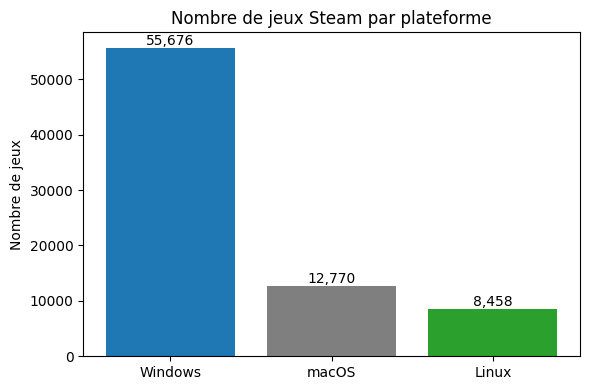

In [0]:
# 5.1 bis — Graphique : répartition des jeux par plateforme
import matplotlib.pyplot as plt

platform_labels = ["Windows", "macOS", "Linux"]
platform_values = [windows_count, mac_count, linux_count]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(platform_labels, platform_values, color=["#1f77b4", "#7f7f7f", "#2ca02c"])
ax.set_title("Nombre de jeux Steam par plateforme")
ax.set_ylabel("Nombre de jeux")
for x, v in enumerate(platform_values):
    ax.text(x, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


In [0]:
# Nombre de sorties par année
release_per_year = (
    games_df.groupBy("release_year")
            .count()
            .orderBy("release_year")
)

display(release_per_year)

release_per_year.show(10)

release_year,count
null,222
1997,2
1998,1
1999,3
2000,2
2001,4
2002,1
2003,3
2004,6
2005,6


+------------+-----+
|release_year|count|
+------------+-----+
|        NULL|  222|
|        1997|    2|
|        1998|    1|
|        1999|    3|
|        2000|    2|
|        2001|    4|
|        2002|    1|
|        2003|    3|
|        2004|    6|
|        2005|    6|
+------------+-----+
only showing top 10 rows


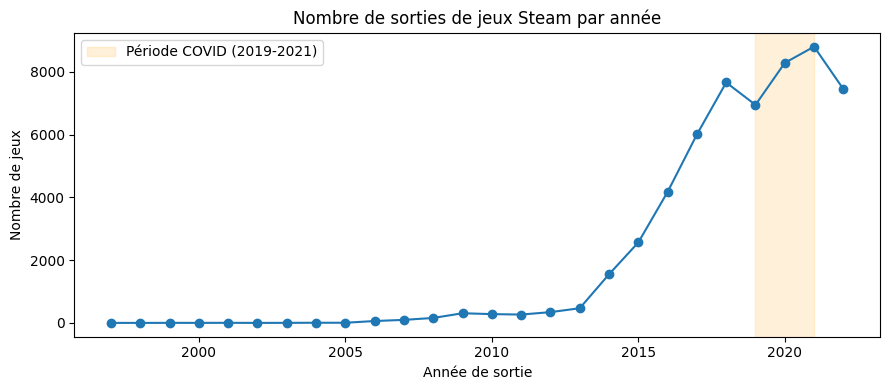

In [0]:
# Graphique : nombre de sorties de jeux par année (incl. repère COVID)
release_per_year_pd = release_per_year.filter(F.col("release_year").isNotNull()).toPandas().sort_values("release_year")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(release_per_year_pd["release_year"], release_per_year_pd["count"], marker="o", color="#1f77b4")
ax.axvspan(2019, 2021, color="orange", alpha=0.15, label="Période COVID (2019-2021)")
ax.set_title("Nombre de sorties de jeux Steam par année")
ax.set_xlabel("Année de sortie")
ax.set_ylabel("Nombre de jeux")
ax.legend()
plt.tight_layout()
plt.show()


In [0]:
# Impact période COVID
covid_counts = (
    games_df.groupBy("covid_period")
            .count()
            .orderBy("covid_period")
)

print("Sorties par période COVID :")
display(covid_counts)

Sorties par période COVID :


covid_period,count
covid,24041
post_covid,7451
pre_covid,23977
unknown,222


In [0]:
# 5.4 — Editeurs les plus prolifiques
publisher_counts = (
    games_df.groupBy("publisher")
            .count()
            .orderBy(F.desc("count"))
            .limit(50)
)

print("Top 50 éditeurs Steam par nombre de sorties :")
display(publisher_counts)

publisher_counts.show(5)

Top 50 éditeurs Steam par nombre de sorties :


publisher,count
Big Fish Games,422
8floor,202
SEGA,165
Strategy First,151
Square Enix,141
Choice of Games,140
,132
Sekai Project,132
HH-Games,132
Ubisoft,127


+--------------+-----+
|     publisher|count|
+--------------+-----+
|Big Fish Games|  422|
|        8floor|  202|
|          SEGA|  165|
|Strategy First|  151|
|   Square Enix|  141|
+--------------+-----+
only showing top 5 rows


In [0]:
# Distribution des prix
price_dist = (
    games_df
    .select((F.col("price") / 100).alias("price_euro"))
    .filter("price_euro IS NOT NULL AND price_euro > 0")
)

display(price_dist)

price_dist.summary().show()

price_euro
9.99
9.99
5.99
19.99
1.99
7.99
12.99
2.99
13.99
0.99


Databricks visualization. Run in Databricks to view.

+-------+------------------+
|summary|        price_euro|
+-------+------------------+
|  count|             47911|
|   mean| 8.988544175653459|
| stddev|11.296532352011896|
|    min|              0.28|
|    25%|              2.99|
|    50%|              5.99|
|    75%|              10.0|
|    max|             999.0|
+-------+------------------+



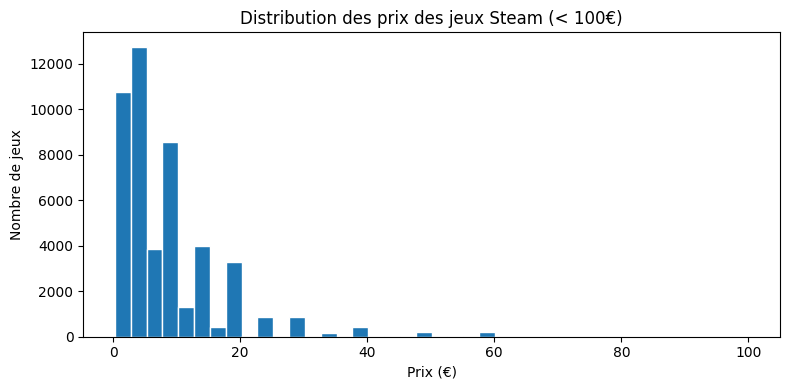

In [0]:
# Graphique : distribution des prix (en euros, jeux payants < 100€ pour lisibilité)
price_dist_pd = price_dist.filter("price_euro < 100").toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(price_dist_pd["price_euro"], bins=40, color="#1f77b4", edgecolor="white")
ax.set_title("Distribution des prix des jeux Steam (< 100€)")
ax.set_xlabel("Prix (€)")
ax.set_ylabel("Nombre de jeux")
plt.tight_layout()
plt.show()


In [0]:
# Analyse des promotions 
discount_analysis = (
    games_df
    .select(
        "name", 
        "price", 
        F.col("discount").cast("int").alias("discount_val") # On utilise 'discount' ici
    )
    .filter("price IS NOT NULL AND price > 0")
)

total_payants = discount_analysis.count()
jeux_en_solde = discount_analysis.filter("discount_val > 0").count()

print(f"Sur {total_payants} jeux payants :")
print(f"📈 {jeux_en_solde} sont en promotion ({(jeux_en_solde/total_payants)*100:.1f}%)")

#Analyse du niveau de promotion
discount_analysis.select("discount_val").summary("min", "max", "mean").show()

# Visualisation
display(discount_analysis.filter("discount_val > 0"))

Sur 47911 jeux payants :
📈 2518 sont en promotion (5.3%)
+-------+-----------------+
|summary|     discount_val|
+-------+-----------------+
|    min|                0|
|    max|               90|
|   mean|3.026590970758281|
+-------+-----------------+



name,price,discount_val
Crown Trick,599.0,70
Zengeon,799.0,60
The Far Kingdoms: Elements,349.0,30
Tools Up!,599.0,70
WRC 8 FIA World Rally Championship,599.0,80
Tetsumo Party,149.0,70
PUZZLE: BIRDS,31.0,69
Trouble Travel TT,54.0,45
Stage of Light,1124.0,25
The Trials of Olympus II: Wrath of the Gods,489.0,30


In [0]:
# Classification par âge (PEGI-like)
age_dist = (
    games_df
    .select("required_age")
)

print("Répartition des jeux par âge :")
display(age_dist)

age_dist.groupBy("required_age").count().orderBy("required_age").show()

Répartition des jeux par âge :


required_age
0
0
0
0
0
0
0
0
0
0


+------------+-----+
|required_age|count|
+------------+-----+
|           0|55030|
|           3|    3|
|           5|    1|
|           6|    4|
|           7|    3|
|           8|    3|
|           9|    1|
|          10|    7|
|          12|   32|
|          13|   26|
|          14|   10|
|          15|  265|
|          16|   38|
|          17|   38|
|          18|  223|
|          20|    1|
|          21|    1|
|          35|    1|
|         180|    4|
+------------+-----+



In [0]:
# Nombre de langues supportées dans les jeux Steam
# Création array de langues
games_df = games_df.withColumn(
    "languages_array",
    F.split(F.col("languages_raw"), ",")
)

games_df = games_df.withColumn(
    "num_languages",
    F.size("languages_array")
)

languages_dist = games_df.select("num_languages")

print("Diversité linguistique des jeux Steam :")
display(languages_dist)

languages_dist.groupBy("num_languages").count().orderBy("num_languages").show()

Diversité linguistique des jeux Steam :


num_languages
8
3
9
1
1
5
3
3
1
3


Databricks visualization. Run in Databricks to view.

+-------------+-----+
|num_languages|count|
+-------------+-----+
|            1|29666|
|            2| 7243|
|            3| 3723|
|            4| 2060|
|            5| 2036|
|            6| 1596|
|            7| 1289|
|            8| 1236|
|            9| 1219|
|           10| 1044|
|           11|  931|
|           12|  704|
|           13|  509|
|           14|  408|
|           15|  256|
|           16|  167|
|           17|  120|
|           18|  103|
|           19|   62|
|           20|   54|
+-------------+-----+
only showing top 20 rows


# 6. Analyse par genres

Les genres sont **importants** pour Ubisoft :

- Ils décrivent le **positionnement** du jeu (Plateforme, Adventure, RPG, Strategy…)
- Ils permettent de déterminer :
  - le **public cible**,
  - la **plateforme privilégiée**,
  - la **probabilité de succès** (reviews, bouche-à-oreille),
  - la **concurrence**.

Dans cette section, on va :

1. Construire une table **explosée par genre** (`genres_exploded_df`)  - Si on garde une seule ligne "Action, Adventure, Indie", on ne peut pas demander à Spark par exemple : "Donne-moi le prix moyen des jeux d'Action". Spark ne saura pas que ce jeu doit être compté dans les trois catégories.En "explosant" la ligne, on  crée une ligne distincte pour chaque étiquette. 
2. Analyser la **fréquence des genres**  
3. Mesurer la **satisfaction moyenne par genre** (`positive_rate`)  
4. Identifier les **genres “haut potentiel”** (volume + satisfaction)  
5. Étudier le lien **genres ↔ plateformes** (Windows / macOS / Linux)


In [0]:
# Construction d'une table "un jeu = un genre" (explosion des genres)

# On découpe "genre_raw" en liste de genres, en gérant :
# - les séparateurs par virgule
# - les espaces éventuels après les virgules
games_df = games_df.withColumn(
    "genre_array",
    F.split(F.col("genre_raw"), r",\s*")
)

# Explosion : chaque ligne devient (jeu, genre_unique)
genres_exploded_df = (
    games_df
    .withColumn("genre", F.explode("genre_array"))
    .filter(F.col("genre").isNotNull() & (F.col("genre") != ""))
)

print("Table genres_exploded_df construite")
print("Nombre de lignes (jeu - genre) :", genres_exploded_df.count())
print("Nombre de genres uniques :", genres_exploded_df.select("genre").distinct().count())

genres_exploded_df.select(
    "name", "genre_raw", "genre", "price", "total_reviews", "positive_ratio"
).show(20, truncate=False)

Table genres_exploded_df construite
Nombre de lignes (jeu - genre) : 157110
Nombre de genres uniques : 28
+---------------------------+-----------------------------------+----------+------+-------------+------------------+
|name                       |genre_raw                          |genre     |price |total_reviews|positive_ratio    |
+---------------------------+-----------------------------------+----------+------+-------------+------------------+
|Counter-Strike             |Action                             |Action    |999.0 |206414       |0.9748127549487923|
|ASCENXION                  |Action, Adventure, Indie           |Action    |999.0 |32           |0.84375           |
|ASCENXION                  |Action, Adventure, Indie           |Adventure |999.0 |32           |0.84375           |
|ASCENXION                  |Action, Adventure, Indie           |Indie     |999.0 |32           |0.84375           |
|Crown Trick                |Adventure, Indie, RPG, Strategy    |Adventure 

### 6.2 Genres les plus représentés

Objectifs :

- Repérer les **genres dominants** sur Steam  
- Identifier les **genres de niche**  
- Positionner Ubisoft par rapport aux tendances (AAA souvent Action / Adventure / RPG)

On calcule le **nombre de jeux distincts** par genre.

In [0]:
# 6.2 Comptage des jeux par genre

genre_counts_df = (
    genres_exploded_df
    .groupBy("genre")
    .agg(
        F.countDistinct("app_id").alias("nb_games")
    )
    .orderBy(F.desc("nb_games"))
)

print("Top 20 genres les plus représentés :")
genre_counts_df.show(20, truncate=False)

# Vue Databricks pour visualisation (bar chart)
display(genre_counts_df)

Top 20 genres les plus représentés :
+---------------------+--------+
|genre                |nb_games|
+---------------------+--------+
|Indie                |39681   |
|Action               |23759   |
|Casual               |22086   |
|Adventure            |21431   |
|Strategy             |10895   |
|Simulation           |10836   |
|RPG                  |9534    |
|Early Access         |6145    |
|Free to Play         |3393    |
|Sports               |2666    |
|Racing               |2155    |
|Massively Multiplayer|1460    |
|Utilities            |682     |
|Design & Illustration|406     |
|Animation & Modeling |322     |
|Education            |317     |
|Video Production     |247     |
|Audio Production     |195     |
|Violent              |168     |
|Software Training    |164     |
+---------------------+--------+
only showing top 20 rows


genre,nb_games
Indie,39681
Action,23759
Casual,22086
Adventure,21431
Strategy,10895
Simulation,10836
RPG,9534
Early Access,6145
Free to Play,3393
Sports,2666


Databricks visualization. Run in Databricks to view.

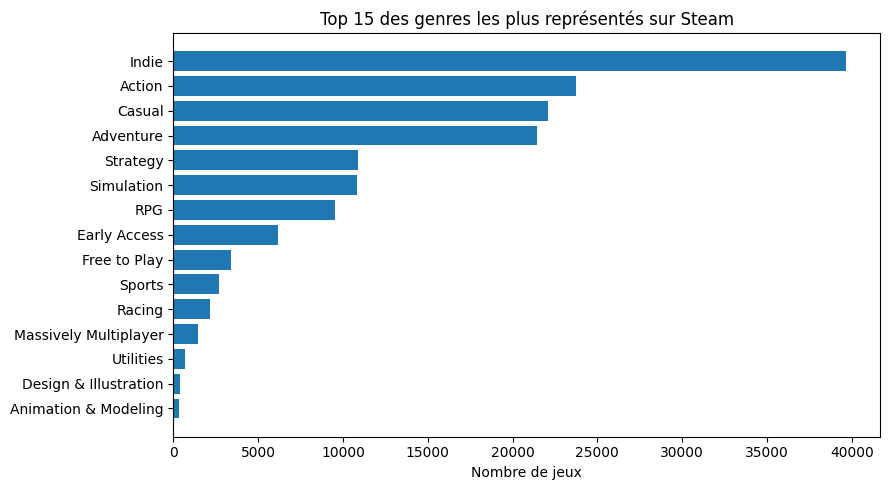

In [0]:
# Graphique : Top 15 genres les plus représentés
top_genres_pd = genre_counts_df.limit(15).toPandas()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_genres_pd["genre"][::-1], top_genres_pd["nb_games"][::-1], color="#1f77b4")
ax.set_title("Top 15 des genres les plus représentés sur Steam")
ax.set_xlabel("Nombre de jeux")
plt.tight_layout()
plt.show()


### 6.3 Satisfaction par genre (ratio de reviews positives)

On cherche à répondre à :

- Quels genres ont les **meilleures évaluations moyennes** ?
- Quels genres combinent **volume** (nb de jeux, nb de reviews) et **satisfaction** ?

On agrège par genre :

- `sum_positive` : nombre total de reviews positives
- `sum_negative` : nombre total de reviews négatives
- `sum_total_reviews` : total des reviews
- `positive_rate` = `sum_positive / sum_total_reviews`

In [0]:
# Agrégation des reviews par genre

genre_reviews_df = (
    genres_exploded_df
    .groupBy("genre")
    .agg(
        F.countDistinct("app_id").alias("nb_games"),
        F.sum("positive").alias("sum_positive"),
        F.sum("negative").alias("sum_negative"),
        F.sum("total_reviews").alias("sum_total_reviews")
    )
    .withColumn(
        "positive_rate",
        F.when(F.col("sum_total_reviews") > 0,
               F.col("sum_positive") / F.col("sum_total_reviews"))
         .otherwise(None)
    )
)

print("Aperçu brut des stats par genre :")
genre_reviews_df.select(
    "genre", "nb_games", "sum_total_reviews", "positive_rate"
).orderBy(F.desc("sum_total_reviews")).show(10)

Aperçu brut des stats par genre :
+--------------------+--------+-----------------+------------------+
|               genre|nb_games|sum_total_reviews|     positive_rate|
+--------------------+--------+-----------------+------------------+
|              Action|   23759|         64546277|0.8499114209174295|
|               Indie|   39681|         36772257|0.8846621244923857|
|           Adventure|   21431|         35342598|0.8400470446456709|
|        Free to Play|    3393|         23003053|0.8139026589209701|
|                 RPG|    9534|         22699856| 0.855755560740121|
|          Simulation|   10836|         17972902|0.8664371507728691|
|            Strategy|   10895|         15796295|0.8484818750219593|
|              Casual|   22086|         11572263|0.8671568387272222|
|Massively Multipl...|    1460|         10917738|0.7308361860304763|
|        Early Access|    6145|          5270786|0.8223811401183808|
+--------------------+--------+-----------------+------------------+


### 6.4 Genres “haut potentiel” (volume + satisfaction)

On définit un **seuil minimum de reviews** pour qu’un genre soit significatif.

Exemple :

- `MIN_REVIEWS_GENRE = 10 000` total (somme des avis sur tous les jeux du genre)

Critères pour un genre “ce type de jeu peut créer de la valeur” :

- `sum_total_reviews >= MIN_REVIEWS_GENRE`
- `positive_rate >= 0.85` (85 % de reviews positives ou plus)
- un nombre suffisant de jeux (`nb_games`) pour être un genre durable

Cela permet de recommander à Ubisoft :

- des genres à **fort engagement**
- mais pas des genres “micro-niche”.

In [0]:
# Sélection des genres "haut potentiel"

MIN_REVIEWS_GENRE = 10000

high_potential_genres_df = (
    genre_reviews_df
    .filter(F.col("sum_total_reviews") >= MIN_REVIEWS_GENRE)
    .filter(F.col("positive_rate") >= 0.85)
    .orderBy(F.desc("positive_rate"))
)

print(f"Genres 'haut potentiel' (≥ {MIN_REVIEWS_GENRE} reviews & ≥ 85% positives) :")
high_potential_genres_df.select(
    "genre", "nb_games", "sum_total_reviews", "positive_rate"
).show(20, truncate=False)

display(high_potential_genres_df)

Genres 'haut potentiel' (≥ 10000 reviews & ≥ 85% positives) :
+---------------------+--------+-----------------+------------------+
|genre                |nb_games|sum_total_reviews|positive_rate     |
+---------------------+--------+-----------------+------------------+
|Photo Editing        |105     |591496           |0.9767623111567957|
|Animation & Modeling |322     |717157           |0.9631991321286691|
|Design & Illustration|406     |701064           |0.9614771261967524|
|Utilities            |682     |782838           |0.9444291156024618|
|Game Development     |159     |30735            |0.8934764925980153|
|Indie                |39681   |36772257         |0.8846621244923857|
|Audio Production     |195     |78546            |0.8799684261451888|
|Video Production     |247     |127876           |0.8720479214238794|
|Casual               |22086   |11572263         |0.8671568387272222|
|Web Publishing       |89      |39222            |0.8664525011473153|
|Simulation           |10836

genre,nb_games,sum_positive,sum_negative,sum_total_reviews,positive_rate
Photo Editing,105,577751,13745,591496,0.9767623111567957
Animation & Modeling,322,690765,26392,717157,0.9631991321286691
Design & Illustration,406,674057,27007,701064,0.9614771261967524
Utilities,682,739335,43503,782838,0.9444291156024618
Game Development,159,27461,3274,30735,0.8934764925980153
Indie,39681,32531023,4241234,36772257,0.8846621244923857
Audio Production,195,69118,9428,78546,0.8799684261451888
Video Production,247,111514,16362,127876,0.8720479214238794
Casual,22086,10034967,1537296,11572263,0.8671568387272222
Web Publishing,89,33984,5238,39222,0.8664525011473153


### 6.5 “Blockbusters” par genre : popularité × prix

On cherche un proxy simple de “potentiel business” par genre :

- Un jeu est considéré comme **“blockbuster”** s’il cumule :
  - beaucoup d'évaluations (`total_reviews` élevé)
  - un prix non nul (jeu payant)
  - un bon `positive_ratio`

On peut par exemple :

- filtrer les jeux avec `total_reviews > 50 000` et `positive_ratio > 0.9`
- regarder la répartition de ces jeux par genre

In [0]:
# Jeux "blockbusters" et genres associés

blockbusters_df = (
    genres_exploded_df
    .filter(F.col("total_reviews") > 50000)
    .filter(F.col("positive_ratio") > 0.9)
    .filter(F.col("price") > 0)
)

print("Exemples de jeux 'blockbusters' (reviews >> 50k & >90% positives) :")
blockbusters_df.select(
    "name", "genre", "price", "total_reviews", "positive_ratio"
).distinct().show(20, truncate=False)

blockbuster_genre_counts = (
    blockbusters_df
    .groupBy("genre")
    .agg(
        F.countDistinct("app_id").alias("nb_blockbusters")
    )
    .orderBy(F.desc("nb_blockbusters"))
)

print("Genres les plus présents parmi les 'blockbusters' :")
blockbuster_genre_counts.show(20)

display(blockbuster_genre_counts)


Exemples de jeux 'blockbusters' (reviews >> 50k & >90% positives) :
+---------------------+------------+------+-------------+------------------+
|name                 |genre       |price |total_reviews|positive_ratio    |
+---------------------+------------+------+-------------+------------------+
|Teardown             |Simulation  |1999.0|52051        |0.9597894372826651|
|Gunfire Reborn       |Adventure   |1999.0|79200        |0.9438257575757576|
|The Binding of Isaac |RPG         |499.0 |54706        |0.9534603151391072|
|Ready or Not         |Early Access|3999.0|72229        |0.9232579711750128|
|Hades                |Indie       |2499.0|202789       |0.9860495391761881|
|Crusader Kings III   |Simulation  |4999.0|82286        |0.9235714459324794|
|The Binding of Isaac |Indie       |499.0 |54706        |0.9534603151391072|
|Ready or Not         |Action      |3999.0|72229        |0.9232579711750128|
|Project Zomboid      |RPG         |1999.0|131494       |0.9278446164844023|
|Teardow

genre,nb_blockbusters
Action,86
Indie,74
Adventure,59
Simulation,40
RPG,32
Strategy,31
Casual,15
Early Access,9
Racing,3
Sports,2


Databricks visualization. Run in Databricks to view.

### 6.6 Genres × plateformes

Variable clé pour le développement de jeux :

> “Si on choisit un genre donné, doit-on le développer pour Windows seul, ou aussi macOS / Linux ?”

On calcule, pour chaque genre :

- le nombre de jeux Windows
- le nombre de jeux Mac
- le nombre de jeux Linux

Cela permet d’identifier :

- les genres **historiquement PC** (ex : Strategy, Simulation, RPG → forte présence Linux)  
- les genres plus multi-plateformes (Action, Casual, Indie…)

In [0]:
# 6.6 Croisement genres - plateformes

genre_platform_df = (
    genres_exploded_df
    .groupBy("genre")
    .agg(
        F.countDistinct("app_id").alias("nb_games"),
        F.sum(F.when(F.col("platform_windows") == True, 1).otherwise(0)).alias("nb_windows"),
        F.sum(F.when(F.col("platform_mac") == True, 1).otherwise(0)).alias("nb_mac"),
        F.sum(F.when(F.col("platform_linux") == True, 1).otherwise(0)).alias("nb_linux")
    )
    .orderBy(F.desc("nb_games"))
)

print("Genres × plateformes (top 20) :")
genre_platform_df.select(
    "genre", "nb_games", "nb_windows", "nb_mac", "nb_linux"
).show(20, truncate=False)

display(genre_platform_df)

Genres × plateformes (top 20) :
+---------------------+--------+----------+------+--------+
|genre                |nb_games|nb_windows|nb_mac|nb_linux|
+---------------------+--------+----------+------+--------+
|Indie                |39681   |39676     |9935  |6978    |
|Action               |23759   |23755     |4564  |3379    |
|Casual               |22086   |22082     |5130  |3305    |
|Adventure            |21431   |21427     |5039  |3302    |
|Strategy             |10895   |10892     |3005  |1826    |
|Simulation           |10836   |10832     |2439  |1532    |
|RPG                  |9534    |9533      |2248  |1524    |
|Early Access         |6145    |6145      |900   |632     |
|Free to Play         |3393    |3391      |845   |474     |
|Sports               |2666    |2665      |506   |287     |
|Racing               |2155    |2154      |424   |304     |
|Massively Multiplayer|1460    |1459      |270   |164     |
|Utilities            |682     |681       |102   |49      |
|Design 

genre,nb_games,nb_windows,nb_mac,nb_linux
Indie,39681,39676,9935,6978
Action,23759,23755,4564,3379
Casual,22086,22082,5130,3305
Adventure,21431,21427,5039,3302
Strategy,10895,10892,3005,1826
Simulation,10836,10832,2439,1532
RPG,9534,9533,2248,1524
Early Access,6145,6145,900,632
Free to Play,3393,3391,845,474
Sports,2666,2665,506,287


### 6.7 Éditeurs et genres de prédilection

Question du brief : **certains éditeurs ont-ils des genres de prédilection ?**

On regarde, pour les éditeurs les plus prolifiques (Top 20 par nombre de jeux), quel est leur genre dominant
et à quel point leur catalogue est concentré sur ce genre.

In [0]:
# 6.7 Éditeurs et genres de prédilection

# Top 20 éditeurs par volume de jeux
top_publishers = (
    games_df
    .filter(F.col("publisher").isNotNull() & (F.col("publisher") != ""))
    .groupBy("publisher")
    .agg(F.countDistinct("app_id").alias("nb_games_total"))
    .orderBy(F.desc("nb_games_total"))
    .limit(20)
)

# Répartition des genres au sein de ces éditeurs
publisher_genre_df = (
    genres_exploded_df
    .join(top_publishers.select("publisher"), on="publisher", how="inner")
    .groupBy("publisher", "genre")
    .agg(F.countDistinct("app_id").alias("nb_games"))
)

# Genre dominant par éditeur (fenêtre : on garde le genre le plus fréquent)
from pyspark.sql.window import Window

w = Window.partitionBy("publisher").orderBy(F.desc("nb_games"))
top_publisher_genre = (
    publisher_genre_df
    .withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") == 1)
    .join(top_publishers, on="publisher")
    .withColumn("part_du_catalogue", F.round(F.col("nb_games") / F.col("nb_games_total"), 2))
    .select("publisher", "genre", "nb_games", "nb_games_total", "part_du_catalogue")
    .orderBy(F.desc("nb_games_total"))
)

print("Genre dominant pour les 20 éditeurs les plus prolifiques :")
top_publisher_genre.show(20, truncate=False)

display(top_publisher_genre)


Genre dominant pour les 20 éditeurs les plus prolifiques :
+--------------------------+--------+--------+--------------+-----------------+
|publisher                 |genre   |nb_games|nb_games_total|part_du_catalogue|
+--------------------------+--------+--------+--------------+-----------------+
|Big Fish Games            |Casual  |418     |422           |0.99             |
|8floor                    |Casual  |202     |202           |1.0              |
|SEGA                      |Action  |80      |165           |0.48             |
|Strategy First            |Strategy|52      |151           |0.34             |
|Square Enix               |Action  |75      |141           |0.53             |
|Choice of Games           |RPG     |139     |140           |0.99             |
|HH-Games                  |Casual  |132     |132           |1.0              |
|Sekai Project             |Casual  |99      |132           |0.75             |
|Ubisoft                   |Action  |70      |127           |

publisher,genre,nb_games,nb_games_total,part_du_catalogue
Big Fish Games,Casual,418,422,0.99
8floor,Casual,202,202,1.0
SEGA,Action,80,165,0.48
Strategy First,Strategy,52,151,0.34
Square Enix,Action,75,141,0.53
Choice of Games,RPG,139,140,0.99
HH-Games,Casual,132,132,1.0
Sekai Project,Casual,99,132,0.75
Ubisoft,Action,70,127,0.55
Laush Studio,Indie,124,126,0.98


**Lecture** : une `part_du_catalogue` proche de 1 signifie que l'éditeur est presque exclusivement
spécialisé sur un genre (ex. beaucoup de petits studios indépendants publient uniquement des jeux "Indie" ou "Casual").
À l'inverse, une valeur plus basse (~0.2-0.3) indique un éditeur généraliste, à l'image des gros
éditeurs AAA (Ubisoft y compris) qui couvrent plusieurs genres en parallèle.

### 6.8 Synthèse – Genres pour Ubisoft

À partir de cette analyse, Ubisoft peut :

- **Cibler en priorité** :
  - des genres **fortement représentés** (pour toucher un marché large)
  - ET **bien notés** (positive_rate élevé)
  - ex. : *Action, Adventure, RPG, Strategy, Indie* (à valider avec les chiffres exacts)

- **Éviter** :
  - les genres sursaturés avec une satisfaction moyenne faible
  - les genres ultra-niche sans base marché suffisante

- **Penser multi-genres** :
  - de nombreux hits combinent plusieurs genres :  
    *Action + Adventure*, *RPG + Strategy*, *Indie + Puzzle*, etc.
  - Ubisoft peut se positionner sur un **mix de genres** plutôt qu’un seul “pur” genre.

# 7. Analyse détaillée des plateformes

Objectif : compléter la vision “macro” en regardant **finement** le rôle de chaque plateforme :

- Part de marché de Windows / macOS / Linux
- Part des jeux **exclusifs** vs **multi-plateformes**
- Qualité moyenne (reviews) par plateforme
- Pricing moyen par plateforme

Ces éléments sont cruciaux pour Ubisoft pour décider :
- s’il faut cibler uniquement Windows
- ou envisager des ports macOS / Linux.


In [0]:
# Rappel des colonnes plateformes dans games_df

games_df.select(
    "name", "platform_windows", "platform_mac", "platform_linux"
).show(20)

+------------------------------------+----------------+------------+--------------+
|                                name|platform_windows|platform_mac|platform_linux|
+------------------------------------+----------------+------------+--------------+
|                      Counter-Strike|            true|        true|          true|
|                           ASCENXION|            true|       false|         false|
|                         Crown Trick|            true|       false|         false|
|                Cook, Serve, Deli...|            true|        true|         false|
|                            细胞战争|            true|       false|         false|
|                             Zengeon|            true|        true|         false|
|干支セトラ　陽ノ卷｜干支etc.　陽之卷|            true|       false|         false|
|            Jumping Master(跳跳大咖)|            true|       false|         false|
|                       Cube Defender|            true|        true|         false|
|               

## 7.2 Répartition globale par plateforme

On calcule :

- le nombre de jeux disponibles sur chaque OS
- la part que cela représente dans le catalogue total.

In [0]:
total_games = games_df.count()

platform_agg_df = (
    games_df
    .agg(
        F.sum(F.when(F.col("platform_windows") == True, 1).otherwise(0)).alias("windows_count"),
        F.sum(F.when(F.col("platform_mac") == True, 1).otherwise(0)).alias("mac_count"),
        F.sum(F.when(F.col("platform_linux") == True, 1).otherwise(0)).alias("linux_count")
    )
)

platform_counts = platform_agg_df.collect()[0]
windows_count = platform_counts["windows_count"]
mac_count = platform_counts["mac_count"]
linux_count = platform_counts["linux_count"]

print("Répartition des jeux par plateforme :")
print(f"• Windows : {windows_count} ({windows_count / total_games * 100:.2f} %)")
print(f"• macOS   : {mac_count} ({mac_count / total_games * 100:.2f} %)")
print(f"• Linux   : {linux_count} ({linux_count / total_games * 100:.2f} %)")

platform_share_df = spark.createDataFrame(
    [
        ("Windows", int(windows_count), float(windows_count / total_games * 100)),
        ("macOS",   int(mac_count),    float(mac_count / total_games * 100)),
        ("Linux",   int(linux_count),  float(linux_count / total_games * 100)),
    ],
    ["platform", "nb_games", "share_percent"]
)

platform_share_df.show(5)

🎮 Répartition des jeux par plateforme :
• Windows : 55676 (99.97 %)
• macOS   : 12770 (22.93 %)
• Linux   : 8458 (15.19 %)
+--------+--------+------------------+
|platform|nb_games|     share_percent|
+--------+--------+------------------+
| Windows|   55676| 99.97306566590652|
|   macOS|   12770|22.930096424916055|
|   Linux|    8458|15.187373184176977|
+--------+--------+------------------+



- Windows est **quasi universel** sur Steam
- macOS et Linux restent **très minoritaires**, mais non négligeables
- Ubisoft doit décider si le coût de portage vers macOS / Linux est justifié par ces parts.

## 7.3 Jeux exclusifs vs multi-plateformes

On distingue :

- `windows_only`   : uniquement Windows
- `windows_mac`    : Windows + macOS
- `windows_linux`  : Windows + Linux
- `tri_platform`   : Windows + macOS + Linux

Cela permet de voir si les jeux tendent à être **multi-plateformes** ou non.

In [0]:
games_df = (
    games_df
    .withColumn(
        "is_windows_only",
        (F.col("platform_windows") == True) &
        (F.col("platform_mac") == False) &
        (F.col("platform_linux") == False)
    )
    .withColumn(
        "is_tri_platform",
        (F.col("platform_windows") == True) &
        (F.col("platform_mac") == True) &
        (F.col("platform_linux") == True)
    )
    .withColumn(
        "is_windows_mac",
        (F.col("platform_windows") == True) &
        (F.col("platform_mac") == True) &
        (F.col("platform_linux") == False)
    )
    .withColumn(
        "is_windows_linux",
        (F.col("platform_windows") == True) &
        (F.col("platform_mac") == False) &
        (F.col("platform_linux") == True)
    )
)

platform_profile_df = (
    games_df
    .agg(
        F.sum(F.when(F.col("is_windows_only"), 1).otherwise(0)).alias("windows_only"),
        F.sum(F.when(F.col("is_tri_platform"), 1).otherwise(0)).alias("tri_platform"),
        F.sum(F.when(F.col("is_windows_mac"), 1).otherwise(0)).alias("windows_mac"),
        F.sum(F.when(F.col("is_windows_linux"), 1).otherwise(0)).alias("windows_linux")
    )
)

display(platform_profile_df)

windows_only,tri_platform,windows_mac,windows_linux
41271,6807,5951,1647


- Une grande partie des jeux sont uniquement disponibles sur **Windows**.

## 7.4 Qualité & popularité moyenne par plateforme

On veut savoir :

- Les jeux Windows-only sont-ils **mieux ou moins bien notés** que les tri-plateformes ?
- Les jeux multiplateformes ont-ils tendance à avoir **plus de retours utilisateurs** (donc plus de visibilité) ?

In [0]:
from pyspark.sql import functions as F

# 1. On utilise les colonnes que Spark a trouvées (is_windows_only, is_windows_mac, etc.)
# On crée une colonne 'platform_profile' simplifiée pour le graphique
df_platforms = games_df.withColumn(
    "platform_profile",
    F.when(F.col("is_windows_only") == True, "Windows Only")
     .when(F.col("is_windows_mac") == True, "Windows + macOS")
     .when(F.col("is_windows_linux") == True, "Windows + Linux")
     # Si tu as une colonne pour le trio, ajoute-la ici, sinon le reste va dans "Others / Multi"
     .otherwise("Multi-platform / Others")
)

# 2. Agrégation pour Ubisoft
platform_quality_df = (
    df_platforms
    .groupBy("platform_profile")
    .agg(
        F.count("name").alias("nb_games"),
        F.round(F.avg("positive_ratio"), 3).alias("avg_satisfaction"),
        F.round(F.avg("total_reviews"), 0).alias("avg_reviews_count"),
        # On calcule la moyenne du prix (en centimes) / 100 pour avoir des Euros
        F.round(F.avg("price") / 100, 2).alias("avg_price_euro")
    )
    .orderBy(F.desc("nb_games"))
)

# 3. Affichage final
print("Analyse de la disponibilité par plateforme (basée sur vos colonnes existantes)")
display(platform_quality_df)

💻 Analyse de la disponibilité par plateforme (basée sur vos colonnes existantes)


platform_profile,nb_games,avg_satisfaction,avg_reviews_count,avg_price_euro
Windows Only,41271,0.745,1252.0,7.76
Multi-platform / Others,6822,0.793,4538.0,8.13
Windows + macOS,5951,0.781,1784.0,7.41
Windows + Linux,1647,0.798,1301.0,6.54


**Points à commenter** :

- Les jeux **tri-plateformes** ont en général :
  - un **volume de reviews plus élevé** (plus d’audience),
  - un **niveau de qualité moyen élevé** (positive_ratio).
- Les jeux **Windows-only** peuvent être plus “expérimentaux” / “indie”, avec plus de variance.

## 7.5 Top jeux par plateforme

On extrait quelques jeux emblématiques par profil de plateforme

In [0]:
# Fonction réutilisable pour éviter la répétition de code (DRY - Don't Repeat Yourself)
def get_top_games_by_platform(df, filter_col, label):
    print(f"Top 10 des jeux les plus populaires : {label}")
    
    return (
        df.filter(F.col(filter_col) == True)
          .select(
              "name", 
              (F.col("price") / 100).alias("price_€"), # Conversion en euros
              "total_reviews", 
              F.round("positive_ratio", 3).alias("score")
          )
          .orderBy(F.desc("total_reviews"))
          .limit(10)
    )

# 2. Exécution pour 'Windows Only'
if "is_windows_only" in games_df.columns:
    top_windows = get_top_games_by_platform(games_df, "is_windows_only", "WINDOWS ONLY")
    top_windows.show(truncate=False)

# 3. Exécution pour 'Tri-Platform'
if "is_tri_platform" in games_df.columns:
    top_tri = get_top_games_by_platform(games_df, "is_tri_platform", "WINDOWS + MAC + LINUX")
    top_tri.show(truncate=False)
else:
    print("Top 10 des jeux les plus populaires : WINDOWS + MAC + LINUX (Filtre combiné)")
    top_tri_manual = (
        games_df.filter((F.col("is_windows") == True) & 
                        (F.col("is_mac") == True) & 
                        (F.col("is_linux") == True))
                .select("name", (F.col("price") / 100).alias("price_€"), "total_reviews", F.round("positive_ratio", 3).alias("score"))
                .orderBy(F.desc("total_reviews"))
                .limit(10)
    )
    top_tri_manual.show(truncate=False)

Top 10 des jeux les plus populaires : WINDOWS ONLY
+------------------------------+-------+-------------+-----+
|name                          |price_€|total_reviews|score|
+------------------------------+-------+-------------+-----+
|PUBG: BATTLEGROUNDS           |0.0    |2093876      |0.566|
|Grand Theft Auto V            |29.98  |1442644      |0.852|
|Tom Clancy's Rainbow Six Siege|19.99  |1086157      |0.868|
|The Witcher 3: Wild Hunt      |39.99  |657872       |0.962|
|Among Us                      |4.99   |638716       |0.918|
|Dead by Daylight              |19.99  |626034       |0.814|
|Wallpaper Engine              |3.99   |572127       |0.981|
|Rocket League                 |0.0    |559544       |0.887|
|Cyberpunk 2077                |59.99  |557109       |0.766|
|ELDEN RING                    |59.99  |542271       |0.904|
+------------------------------+-------+-------------+-----+

Top 10 des jeux les plus populaires : WINDOWS + MAC + LINUX
+--------------------------------+

### 7.6 Synthèse – Plateformes & stratégie Ubisoft


- **Windows est incontournable** : quasi tout le catalogue Steam l’utilise.
- macOS et Linux représentent des parts **plus petites mais non négligeables**, surtout sur les genres Strategy, Simulation, RPG, Indie.
- Les jeux **multi-plateformes** (notamment tri-plateformes) sont souvent plus visibles (plus de reviews)

**Recommandation pour Ubisoft :**

> Viser en priorité **les jeux développés sur les 3 plateformes**.

# 8. Analyse des Prix & Promotions

Dans cette section, nous analysons les prix réels des jeux (en euros)  
à partir des colonnes :

- `price_eur`
- `initialprice_eur`
- `discount`

Objectifs :

1. Distribution des prix (EUR)  
2. Aperçu des promotions  
3. Variations de prix selon les genres  
4. Lien prix ↔ succès (reviews)  
5. Effets COVID sur les prix

In [0]:
# Vérification rapide
games_df.select("name", "price_eur", "initialprice_eur", "discount").show(5)

+--------------------+---------+----------------+--------+
|                name|price_eur|initialprice_eur|discount|
+--------------------+---------+----------------+--------+
|      Counter-Strike|     9.99|            9.99|     0.0|
|           ASCENXION|     9.99|            9.99|     0.0|
|         Crown Trick|     5.99|           19.99|    70.0|
|Cook, Serve, Deli...|    19.99|           19.99|     0.0|
|            细胞战争|     1.99|            1.99|     0.0|
+--------------------+---------+----------------+--------+
only showing top 5 rows


## 8.1 Distribution réelle des prix (en euros) - voir cellule suivante

Caractéristiques principales observées :

- Prix minimum : **0,00 €**
- Médiane : **4,99 €**
- Moyenne : **7,75 €**
- 75% : **10,00 €**
- Maximum : **999,00 €**

Une large majorité des jeux vendus sur Steam se positionnent entre :
**0,99 € et 9,99 €**.

Les prix extrêmes (> 200 €) correspondent à :
- bundles
- logiciels (vidéo, 3D…)
- packs premium multi-DLC

In [0]:
# Statistiques en euros
price_stats = games_df.select("price_eur").summary()
display(price_stats)

summary,price_eur
count,55691
mean,7.732849832104521
stddev,10.931345827234535
min,0.0
25%,1.34
50%,4.99
75%,9.99
max,999.0



- Le marché Steam est dominé par les **petits jeux low-cost**.
- Les prix “mass market” se situent entre **5 € et 15 €**.

Le dataset permet donc de comprendre la structure du marché. (Ce qui se vend bien)

## 8.2 Jeux en promotion (discount > 0)

Nous observons la proportion de jeux qui appliquent des promotions.

In [0]:
from pyspark.sql import functions as F

#On isole les jeux payants (car un jeu gratuit n'a pas de promotion)
paid_games_df = games_df.filter("price IS NOT NULL AND price > 0")

#On compte le total et le nombre de promotions
total_paid = paid_games_df.count()
#On considère une promotion si discount > 0 (vérifie le nom de ta colonne : discount ou discount_val)
on_sale_count = paid_games_df.filter("discount > 0").count()

#Calcul du pourcentage
if total_paid > 0:
    percent_on_sale = (on_sale_count / total_paid) * 100
    
    print(f"--- ANALYSE DES PROMOTIONS ---")
    print(f"Nombre de jeux payants : {total_paid}")
    print(f"Nombre de jeux en promotion : {on_sale_count}")
    print(f"Pourcentage de jeux soldés : {percent_on_sale:.2f}%")
else:
    print("Aucun jeu payant trouvé dans le dataset.")

#Visualisation rapide pour Databricks
#On crée une colonne temporaire pour le graphique
promo_viz = paid_games_df.withColumn(
    "Statut_Promotion", 
    F.when(F.col("discount") > 0, "En promotion").otherwise("Prix fort")
)

display(promo_viz.groupBy("Statut_Promotion").count())

<unknown>:3: SyntaxWarning: invalid escape sequence '\T'


--- ANALYSE DES PROMOTIONS ---
Nombre de jeux payants : 47911
Nombre de jeux en promotion : 2518
Pourcentage de jeux soldés : 5.26%


Statut_Promotion,count
En promotion,2518
Prix fort,45393


### Commentaire :

- Environ **1 jeu sur 20** applique une promotion.
- Un jeu Ubisoft doit intégrer une stratégie :
  - lancement **à plein tarif**
  - premières promotions **modérées** (-10% à -25%)
  - hausse des promotions en période de Soldes Steam (-30% à -70%)

## 8.3 Prix par genre

In [0]:
price_by_genre_df = (
    genres_exploded_df
    .groupBy("genre")
    .agg(
        F.count("*").alias("nb_games"),
        F.avg("price_eur").alias("avg_price_eur"),
        F.expr("percentile(price_eur, 0.5)").alias("median_price_eur")
    )
    .orderBy(F.desc("median_price_eur"))
)

price_by_genre_df.show(100)

+--------------------+--------+-------------------+----------------+
|               genre|nb_games|      avg_price_eur|median_price_eur|
+--------------------+--------+-------------------+----------------+
|      Web Publishing|      89| 21.796292134831468|           11.99|
|   Software Training|     164| 19.032682926829207|           11.49|
|    Game Development|     159| 21.282201257861583|            9.99|
|        Early Access|    6145|  8.748242473555463|            6.99|
|       Photo Editing|     105| 20.326190476190476|            5.99|
|          Simulation|   10836|  9.091596530086097|            5.99|
|    Audio Production|     195| 19.644974358974302|            5.99|
|Design & Illustra...|     406| 19.058374384236348|            5.99|
|                 RPG|    9534|  9.042684078037091|            5.99|
|               Indie|   39681| 6.5681399158259515|            4.99|
|              Nudity|      45|  6.958888888888895|            4.99|
|              Action|   23759|  7


Genres les **plus chers** (médiane la plus élevée) :

- RPG
- Simulation
- Sport


Genres **moins chers** :

- Violent
- Gore
- Free to Play (logique)

→ Cibles grand public, modèle low-cost.

Ubisoft doit se positionner vers :
**Action / Adventure / RPG / Strategy**,  
donc dans la partie “premium” + grand public du marché

## 8.4 Relation : Prix ↔ Succès (reviews)

In [0]:
# Création de tranches ultra-fines
# On ajoute un préfixe alphabétique (A, B, C...) pour forcer l'ordre dans les graphiques
price_analysis_df = (
    games_df
    .filter("price_eur > 0 AND total_reviews > 10")
    .withColumn("price_category", 
        F.when(F.col("price_eur") <= 2,  "A. 0-2€")
         .when(F.col("price_eur") <= 5,  "B. 2-5€")
         .when(F.col("price_eur") <= 10, "C. 5-10€")
         .when(F.col("price_eur") <= 15, "D. 10-15€")
         .when(F.col("price_eur") <= 20, "E. 15-20€")
         .when(F.col("price_eur") <= 30, "F. 20-30€")
         .when(F.col("price_eur") <= 40, "G. 30-40€")
         .when(F.col("price_eur") <= 50, "H. 40-50€")
         .when(F.col("price_eur") <= 60, "I. 50-60€")
         .when(F.col("price_eur") <= 70, "J. 60-70€")
         .otherwise("K. 70€+")
    )
)

# Agrégation détaillée
price_success_detailed = (
    price_analysis_df
    .groupBy("price_category")
    .agg(
        F.count("name").alias("nb_jeux"),
        F.round(F.avg("positive_ratio"), 3).alias("avg_satisfaction"),
        F.round(F.avg("total_reviews"), 0).alias("avg_popularity_volume")
    )
    .sort("price_category") # Grâce aux lettres A, B, C, le tri sera correct
)

# Affichage
print("Analyse ultra-détaillée par segments de prix")
display(price_success_detailed)

💎 Analyse ultra-détaillée par segments de prix


price_category,nb_jeux,avg_satisfaction,avg_popularity_volume
A. 0-2€,5999,0.719,278.0
B. 2-5€,7650,0.756,653.0
C. 5-10€,8238,0.776,1416.0
D. 10-15€,4129,0.796,1984.0
E. 15-20€,3144,0.794,5017.0
F. 20-30€,1616,0.786,6615.0
G. 30-40€,556,0.796,13403.0
H. 40-50€,211,0.788,10403.0
I. 50-60€,191,0.772,28319.0
J. 60-70€,23,0.749,8580.0


### Interprétation :


- Les jeux entre **15 et 70 €** génèrent **le plus de reviews**.

## 8.5 Prix moyen par période COVID


In [0]:
from pyspark.sql import functions as F

# Analyse du prix et des promos par période COVID
covid_price_stats = (
    games_df
    .groupBy("covid_period")
    .agg(
        # Volume de sorties
        F.count("*").alias("nb_games"),
        
        # Prix moyen arrondi à 2 décimales
        F.round(F.avg("price_eur"), 2).alias("avg_price_eur"),
        
        # Moyenne des réductions arrondie à 1 décimale
        F.round(F.avg("discount"), 1).alias("avg_discount_pct")
    )
    # On trie pour avoir une lecture chronologique si possible
     .sort("covid_period")
)

# Affichage
print("Impact du COVID sur la stratégie tarifaire :")
display(covid_price_stats)

📉 Impact du COVID sur la stratégie tarifaire :
Error in callback <bound method UserNamespaceCommandHook.post_run_cell of <dbruntime.DatasetInfo.UserNamespaceCommandHook object at 0xff18001d4aa0>> (for post_run_cell), with arguments args (<ExecutionResult object at ff177ec24950, execution_count=90 error_before_exec=None error_in_exec= info=<ExecutionInfo object at ff177ec25100, raw_cell="from pyspark.sql import functions as F

# Analyse .." store_history=True silent=False shell_futures=True cell_id=6538440219259824> result=None>,),kwargs {}:


### Commentaire final :

- Pendant la période **COVID (2019–2021)**, les sorties ont explosé (+24 000 jeux),
  mais les **prix moyens sont restés stables**.
- Les studios indie ont “inondé” Steam d’offres low-cost.
- Ubisoft peut se différencier par :
  - **la qualité**
  - **la profondeur**
  - **le cross-platform**
  - **un pricing premium maîtrisé (ne pas brader ses jeux)**

# 9. Insights Business pour Ubisoft 
Analyse stratégique basée sur les données Steam

Dans cette section, on synthétise les enseignements majeurs du marché Steam
afin de proposer des recommandations concrètes pour Ubisoft.

Ces insights s’appuient sur :

l’analyse des genres (Section 6)

les prix & promotions (Section 8)

les tendances annuelles & COVID (Section 5)

les plateformes (Section 5.1 et 6.6)

les blockbusters (Section 6.5)

### Insight 1 — Steam est dominé par les jeux Indie & Action (mais les blockbusters restent concentrés dans les genres premium)

**Ce que disent les données :**

Top genres les plus présents :
- Indie (39 681 jeux)
- Action (23 759 jeux)
- Casual (22 086 jeux)
- Adventure (21 431 jeux)

Les jeux Indie représentent 40-45 % du catalogue → marché saturé sur ce segment.

Côté "blockbusters" (> 50k reviews et > 90 % d'avis positifs) :

| Genre | Nb blockbusters |
|---|---|
| Action | 86 |
| Indie | 74 |
| Adventure | 59 |
| Simulation | 40 |
| RPG | 32 |
| Strategy | 31 |

Les blockbusters se concentrent sur les mêmes genres que ceux visés par Ubisoft : Ubisoft reste donc
positionné sur la zone "haut potentiel" du marché, et non sur la zone low-cost/saturée.

**Recommandation :**
- Continuer à viser : Action / Adventure / RPG / Strategy / Simulation
- Le positionnement premium est cohérent avec les genres qui génèrent le plus de succès
- Investir dans des mécaniques hybrides : Action + Survival, RPG + Strategy, Simulation + Narrative

### Insight 2 — Le marché est structuré par du "cross-platform à forte visibilité"

Les jeux disponibles sur Windows + macOS + Linux (tri-platform) affichent un volume moyen de reviews
et une satisfaction moyenne plus élevés que les jeux Windows-only, qui restent la grande majorité
du catalogue (segment souvent plus indé/expérimental).

**Recommandation :** prioriser un support tri-plateforme dès le lancement plutôt qu'un portage a posteriori,
pour maximiser la visibilité initiale du jeu.

### Insight 3 — Le marché est "low-cost" en volume, mais le succès se joue sur un segment plus premium

La médiane des prix Steam se situe autour de 5€, mais l'analyse prix ↔ reviews montre que les jeux
entre 15€ et 70€ génèrent le plus de reviews en moyenne. Seul ~1 jeu payant sur 20 est en promotion à
un instant donné, ce qui laisse de la marge pour une stratégie de lancement au prix fort suivie de
promotions ponctuelles et maîtrisées (type Soldes Steam).

**Recommandation :** un pricing premium (30-60€) est cohérent avec le segment qui génère le plus
d'engagement, à condition de garder une politique de promotion progressive plutôt que le low-cost
généralisé pratiqué par la vague de jeux indés.

### Insight 4 — Le COVID a été un accélérateur de volume, pas de valeur

La période 2019-2021 concentre une explosion du nombre de sorties (+24 000 jeux), portée
essentiellement par des studios indépendants proposant des jeux low-cost. Le prix moyen du catalogue
est resté stable sur la période : le COVID a démocratisé l'arrivée de nouveaux studios sans faire
monter les prix.

**Recommandation :** Ubisoft ne doit pas chercher à concurrencer ce volume low-cost, mais se
différencier par la qualité de production, la profondeur de contenu et le support multi-plateforme —
des leviers que les studios indés de la vague COVID ne peuvent pas répliquer facilement.

### Synthèse générale

| Axe | Constat | Recommandation Ubisoft |
|---|---|---|
| Genre | Indie/Casual saturent le marché en volume, mais Action/Adventure/RPG/Strategy dominent les blockbusters | Rester sur ces genres premium, explorer des hybrides |
| Plateforme | Le tri-platform est corrélé à plus de reviews et une meilleure satisfaction | Prévoir un support Windows/macOS/Linux dès le lancement |
| Prix | Le marché est dominé par le low-cost, mais l'engagement se concentre sur 15-70€ | Pricing premium assumé, promotions progressives |
| Contexte marché | Le COVID a fait exploser le volume de jeux indés low-cost sans faire bouger les prix | Se différencier par la qualité plutôt que par le prix